# Chapter 3: CVaR Optimisation & Portfolio Analysis

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.optimize import linprog

# portfolios
lr_portfolio = pd.read_csv('data/predictions/lr_portfolio.csv')
mlp_portfolio = pd.read_csv('data/predictions/mlp_portfolio.csv')
rf_portfolio = pd.read_csv('data/predictions/rf_portfolio.csv')
xgb_portfolio = pd.read_csv('data/predictions/xgb_portfolio.csv')
lgbm_portfolio = pd.read_csv('data/predictions/lgbm_portfolio.csv')

In [4]:
lr_portfolio.head()

,id,loan_amnt,int_rate,term,grade,purpose,home_ownership,application_income,loan_status,pd
0,1349345,10000.0,14.65,36,C,credit_card,RENT,50000.0,1,0.254486
1,95046538,7500.0,10.49,36,B,debt_consolidation,MORTGAGE,80000.0,0,0.105658
2,81405218,8400.0,25.44,36,F,debt_consolidation,RENT,28000.0,0,0.471985
3,17222736,28000.0,14.49,60,C,credit_card,RENT,150000.0,0,0.313372
4,69442857,12000.0,6.49,36,A,debt_consolidation,MORTGAGE,45000.0,0,0.051545


In [5]:
sensitivity_map = {
    'A': 0.05, 'B': 0.10, 'C': 0.15,
    'D': 0.20, 'E': 0.25, 'F': 0.30,
    'G': 0.35
}

def portfolio_prep(df):
    lgd = 0.4
    df = df.copy()
    df['expected_loss'] = (df['pd'] * lgd * df['loan_amnt']).round(2) 
    df['int_income'] = (df['loan_amnt'] * (df['int_rate'] / 100)).round(2)
    df['expected_profit'] = (df['int_income'] - df['expected_loss']).round(2)
    df['sensitivity'] = df['grade'].map(sensitivity_map)
    return df

lr_portfolio = portfolio_prep(lr_portfolio)
mlp_portfolio = portfolio_prep(mlp_portfolio)
rf_portfolio = portfolio_prep(rf_portfolio)
xgb_portfolio = portfolio_prep(xgb_portfolio)
lgbm_portfolio = portfolio_prep(lgbm_portfolio)

lr_portfolio.head()

,id,loan_amnt,int_rate,term,grade,purpose,home_ownership,application_income,loan_status,pd,expected_loss,int_income,expected_profit,sensitivity
0,1349345,10000.0,14.65,36,C,credit_card,RENT,50000.0,1,0.254486,1017.94,1465.00,447.06,0.15
1,95046538,7500.0,10.49,36,B,debt_consolidation,MORTGAGE,80000.0,0,0.105658,316.97,786.75,469.78,0.10
2,81405218,8400.0,25.44,36,F,debt_consolidation,RENT,28000.0,0,0.471985,1585.87,2136.96,551.09,0.30
3,17222736,28000.0,14.49,60,C,credit_card,RENT,150000.0,0,0.313372,3509.77,4057.20,547.43,0.15
4,69442857,12000.0,6.49,36,A,debt_consolidation,MORTGAGE,45000.0,0,0.051545,247.41,778.80,531.39,0.05


In [6]:
port_profits = [
    ('Logistic Regression', lr_portfolio), 
    ('MLP', mlp_portfolio),
    ('Random Forest', rf_portfolio), 
    ('XGBoost', xgb_portfolio),
    ('LightGBM', lgbm_portfolio)
]

neg_profit_pct = []
for name, portfolio in port_profits:
    n_negative = (portfolio['expected_profit'] < 0).sum()
    negative_pct = n_negative / len(portfolio)
    neg_profit_pct.append((name, negative_pct))

neg_profit_df = pd.DataFrame(neg_profit_pct, columns=['Portfolio', 'Percent'])
neg_profit_df = neg_profit_df.sort_values('Percent', ascending=False, ignore_index=True)

neg_profit_df


,Portfolio,Percent
0,Random Forest,0.086916
1,XGBoost,0.072628
2,LightGBM,0.042827
3,Logistic Regression,0.033396
4,MLP,0.023414


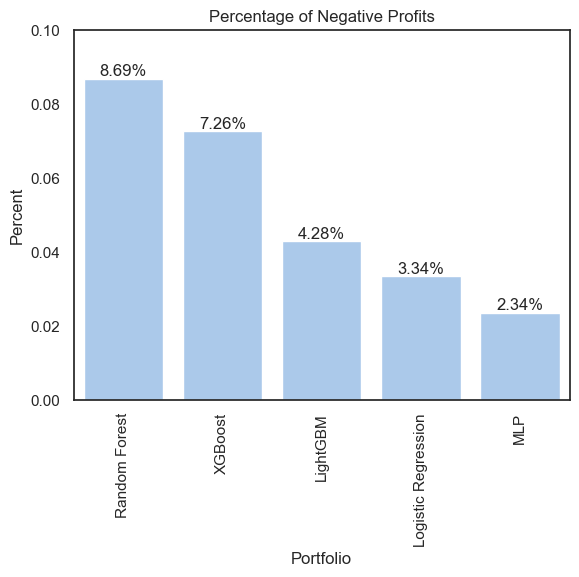

In [7]:
sns.set_theme(style='white', palette='pastel')

negatives_ax = sns.barplot(data=neg_profit_df, x='Portfolio', y='Percent')
for container in negatives_ax.containers:
    negatives_ax.bar_label(container, fmt='{:,.2%}')
plt.title('Percentage of Negative Profits')
plt.ylim(0, 0.1)
plt.xticks(rotation=90)
plt.show()

## Monte Carlo Simulation

In [8]:
def monte_carlo_sim(portfolio_df):
    np.random.seed(42)

    portfolio = portfolio_df.copy()
    n_scenarios = 1000
    lgd = 0.4
    
    # systematic shock - negative = bad economy, positive = good economy
    systematic_shock = np.random.normal(0, 1, size=n_scenarios)

    # adjusted PDs by shock scaled by loan grade sensitivity
    adjusted_pd = (
        portfolio['pd'].values +
        np.outer(systematic_shock, portfolio['sensitivity'].values)
    )
    adjusted_pd = np.clip(adjusted_pd, 0, 1)

    # check if the loan defaults, given adjusted PD
    # default_matrix = np.random.binomial(adjusted_pd, 0, 1)
    default_matrix = np.random.binomial(1, adjusted_pd)

    # loss matrix (losses for each loan per scenario)
    loss_matrix = default_matrix * (lgd * portfolio['loan_amnt'].values)

    # total portfolio loss per scenario
    scenario_losses = loss_matrix.sum(axis=1)

    return loss_matrix, scenario_losses

# baseline model & portfolio 
lr_loss_matrix, lr_scenario_losses = monte_carlo_sim(lr_portfolio)

In [9]:
print(f'Mean Sceanario Loss: ${lr_scenario_losses.mean():,.2f}')
print(f'Minimum Sceanario Loss: ${lr_scenario_losses.min():,.2f}')
print(f'Maxixmum Sceanario Loss: ${lr_scenario_losses.max():,.2f}')

Mean Sceanario Loss: $344,645,583.17
Minimum Sceanario Loss: $57,460.00
Maxixmum Sceanario Loss: $1,072,670,640.00


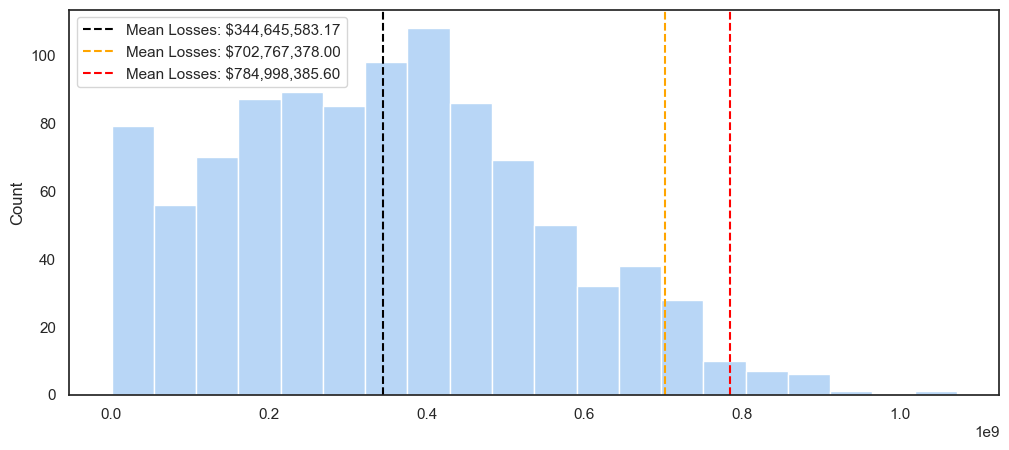

In [10]:
# var & cvar 
base_var = np.percentile(lr_scenario_losses, 95)
base_tail = lr_scenario_losses[lr_scenario_losses >= base_var]
base_cvar = base_tail.mean()

plt.figure(figsize=(12, 5))
sns.histplot(lr_scenario_losses, bins=20)
plt.axvline(lr_scenario_losses.mean(), c='black', ls='--', label=f'Mean Losses: ${lr_scenario_losses.mean():,.2f}')
plt.axvline(base_var, c='orange', ls='--', label=f'Mean Losses: ${base_var:,.2f}')
plt.axvline(base_cvar, c='red', ls='--', label=f'Mean Losses: ${base_cvar:,.2f}')
plt.legend()
plt.show()

In [11]:
# matrices for all other model portfolios
mlp_loss_matrix, mlp_scenario_losses = monte_carlo_sim(mlp_portfolio)
rf_loss_matrix, rf_scenario_losses = monte_carlo_sim(rf_portfolio)
xgb_loss_matrix, xgb_scenario_losses = monte_carlo_sim(xgb_portfolio)
lgbm_loss_matrix, lgbm_scenario_losses = monte_carlo_sim(lgbm_portfolio)

In [12]:
def simulation_summary(name, scenario_losses):
    var  = np.percentile(scenario_losses, 95)
    tail = scenario_losses[scenario_losses >= var]
    cvar = tail.mean()
    print(f'\n{name}')
    print(f'Mean scenario loss: ${scenario_losses.mean():,.2f}')
    print(f'Worst scenario: ${scenario_losses.max():,.2f}')
    print(f'VaR (95%): ${var:,.2f}')
    print(f'CVaR (95%): ${cvar:,.2f}')
    print(f'Global CVaR limit: ${base_cvar:,.2f}')
    print(f'Exceeds limit?: {'YES' if cvar > base_cvar else 'no'}')

simulation_summary('MLP', mlp_scenario_losses)
simulation_summary('Random Forest', rf_scenario_losses)
simulation_summary('XGBoost', xgb_scenario_losses)
simulation_summary('LightGBM', lgbm_scenario_losses)


MLP
Mean scenario loss: $305,542,678.86
Worst scenario: $1,037,353,190.00
VaR (95%): $659,290,288.50
CVaR (95%): $742,195,893.20
Global CVaR limit: $784,998,385.60
Exceeds limit?: no

Random Forest
Mean scenario loss: $359,080,122.89
Worst scenario: $1,081,890,090.00
VaR (95%): $715,862,681.00
CVaR (95%): $798,221,437.60
Global CVaR limit: $784,998,385.60
Exceeds limit?: YES

XGBoost
Mean scenario loss: $346,769,301.47
Worst scenario: $1,069,337,500.00
VaR (95%): $701,527,068.00
CVaR (95%): $784,462,012.20
Global CVaR limit: $784,998,385.60
Exceeds limit?: no

LightGBM
Mean scenario loss: $342,610,343.33
Worst scenario: $1,070,229,500.00
VaR (95%): $701,118,563.00
CVaR (95%): $784,432,813.80
Global CVaR limit: $784,998,385.60
Exceeds limit?: no


### Constraints

In [11]:
total_port_len = len(lr_portfolio)
total_port_capital = lr_portfolio['loan_amnt'].sum().round(2)

print('Pre-Optimisation Stats -')
print(f'Total Loan Applications: {total_port_len:,.0f}')
print(f'Total Capital Required: ${total_port_capital:,.2f}')

Pre-Optimisation Stats -
Total Loan Applications: 268,685
Total Capital Required: $3,877,851,425.00


In [12]:
def get_constraints(scenario_losses, cvar_pct=0.15):
    # capital budget
    capital_limit = 100_000_000

    # VaR
    var = np.percentile(scenario_losses, 95)
    tail_losses = scenario_losses[scenario_losses >= var]
    cvar_full_pool = tail_losses.mean() # reference point

    # CVaR limit - scaled to capital budget
    cvar_limit = cvar_pct * capital_limit

    constraints = {
        'capital_limit': capital_limit,
        'var': var,
        'cvar_limit': cvar_limit,
        'cvar_full_pool': cvar_full_pool,
    } 

    return constraints

global_constraints = get_constraints(lr_scenario_losses)

print('Defined Constraints -')
print(f'Capital Limit: ${global_constraints['capital_limit']:,.2f}')
print(f'CVaR Limit: ${global_constraints['cvar_limit']:,.2f}')

Defined Constraints -
Capital Limit: $100,000,000.00
CVaR Limit: $15,000,000.00


## Optimisation

In [ ]:
def cvar_optimise(portfolio_df, loss_matrix, constraints, binary_threshold=0.99):

    portfolio = portfolio_df.copy().reset_index(drop=True)
    n_scenarios = loss_matrix.shape[0]
    n_loans = len(portfolio)
    confidence = 0.95
    alpha = 1 - confidence

    capital_limit = constraints['capital_limit']
    cvar_limit = constraints['cvar_limit']

    # objective: maximise profit - minimise negative profit
    c = np.concatenate([
        -portfolio['expected_profit'].values,  # negate for minimisation
        [0],  # zeta
        np.zeros(n_scenarios)  # u
    ])

    A_ub, b_ub = [], []

    # u >= 0, -u <= 0
    for s in range(n_scenarios):
        row = np.zeros(1 + n_loans + n_scenarios)
        row[n_loans + 1 + s] = -1
        A_ub.append(row)
        b_ub.append(0)

    # u >= scenario_loss - zeta, loss@x - zeta - u <= 0 
    for s in range(n_scenarios):
        row = np.zeros(1 + n_loans + n_scenarios)
        row[:n_loans] = loss_matrix[s]
        row[n_loans] = -1
        row[n_loans + 1 + s] = -1
        A_ub.append(row)
        b_ub.append(0)

    # CVaR constraint: zeta + (1/alpha*S)*sum(u) <= cvar_limit 
    cvar_row = np.zeros(1 + n_loans + n_scenarios)
    cvar_row[n_loans] = 1
    cvar_row[n_loans + 1:] = 1 / (alpha * n_scenarios)
    A_ub.append(cvar_row)
    b_ub.append(cvar_limit)

    # capital constraint: loan_amnt @ x <= capital_limit
    cap_row = np.zeros(1 + n_loans + n_scenarios)
    cap_row[:n_loans] = portfolio['loan_amnt'].values
    A_ub.append(cap_row)
    b_ub.append(capital_limit)

    A_ub = np.array(A_ub)
    b_ub = np.array(b_ub)

    # bounds: x in [0,1], zeta unbounded, u >= 0 
    bounds = (
        [(0, 1)] * n_loans +  # loan weights
        [(None, None)] +  # zeta
        [(0, None)] * n_scenarios      # u
    )

    # solve 
    result = linprog(
        c, A_ub=A_ub, b_ub=b_ub,
        bounds=bounds, method='highs'
    )

    if result.status != 0:
        print(f"Warning: solver did not converge — {result.message}")
        return None, None

    # --- extract results ---
    weights = result.x[:n_loans]
    portfolio['weight'] = weights
    
    # apply relaxation + rounding if threshold is set
    if binary_threshold is not None:
        portfolio['accepted'] = (portfolio['weight'] >= binary_threshold).astype(int)
        portfolio.loc[portfolio['accepted'] == 1, 'weight'] = 1.0  # round up to 1
    else:
        portfolio['accepted'] = (portfolio['weight'] > 0.01).astype(int)
    
    selected = portfolio[portfolio['accepted'] == 1].copy()

    # weighted capital and profit for the selected portfolio
    capital_used = (selected['loan_amnt'] * selected['weight']).sum()
    total_profit = (selected['expected_profit'] * selected['weight']).sum()
    total_exp_loss = (selected['expected_loss'] * selected['weight']).sum()

    # realised CVaR using the selected portfolio weights
    accepted_idx = portfolio['accepted'].values == 1
    accepted_weights = portfolio.loc[accepted_idx, 'weight'].to_numpy()
    selected_losses = (loss_matrix[:, accepted_idx] * accepted_weights[None, :]).sum(axis=1)
    var_realised = np.percentile(selected_losses, confidence * 100)
    cvar_realised = selected_losses[selected_losses >= var_realised].mean()

    # summary statistics
    summary = {
        'loans_selected': len(selected),
        'capital_used': capital_used,
        'capital_limit': capital_limit,
        'total_profit': total_profit,
        'total_exp_loss': total_exp_loss,
        'avg_pd': selected['pd'].mean() if len(selected) > 0 else np.nan,
        'var_realised': var_realised,
        'cvar_realised': cvar_realised,
        'cvar_limit': cvar_limit,
        'binary_threshold': binary_threshold
    }

    print(f"\nLoans selected: {len(selected)} / {len(portfolio)}")
    if binary_threshold is not None:
        print(f"(Relaxation + rounding applied with threshold={binary_threshold})")
    print(f"Capital used: £{capital_used:,.2f}")
    print(f"Total Profit: £{total_profit:,.2f}")
    print(f"Realised CVaR: £{cvar_realised:,.2f} (CVaR Limit: £{cvar_limit:,.2f})")

    return selected, summary


### Logisitc Regression (Baseline)

In [14]:
# baseline
lr_selected, lr_summary = cvar_optimise(lr_portfolio, lr_loss_matrix, global_constraints)


Loans selected: 8838 / 268685
(Relaxation + rounding applied with threshold=0.99)
Capital used: £99,692,425.00
Total Profit: £10,186,536.47
Realised CVaR: £14,953,820.60 (CVaR Limit: £15,000,000.00)


In [15]:
lr_selected.head()

,id,loan_amnt,int_rate,term,grade,purpose,home_ownership,application_income,loan_status,pd,expected_loss,int_income,expected_profit,sensitivity,weight,accepted
31,110726649,21600.0,24.85,36,E,debt_consolidation,MORTGAGE,60000.0,0,0.262731,2270.00,5367.60,3097.60,0.25,1.0,1
40,90168013,1600.0,15.59,36,C,major_purchase,MORTGAGE,30000.0,0,0.130492,83.51,249.44,165.93,0.15,1.0,1
45,140320641,2000.0,11.55,36,B,debt_consolidation,MORTGAGE,50000.0,1,0.064101,51.28,231.00,179.72,0.10,1.0,1
61,93267865,10000.0,18.99,36,D,credit_card,MORTGAGE,110000.0,0,0.154717,618.87,1899.00,1280.13,0.20,1.0,1
75,3849076,11000.0,15.31,36,C,other,MORTGAGE,119900.0,0,0.109009,479.64,1684.10,1204.46,0.15,1.0,1


### MLP Neural Network

In [16]:
mlp_selected, mlp_summary = cvar_optimise(mlp_portfolio, mlp_loss_matrix, global_constraints)


Loans selected: 8878 / 268685
(Relaxation + rounding applied with threshold=0.99)
Capital used: £99,742,400.00
Total Profit: £11,631,438.86
Realised CVaR: £14,964,166.00 (CVaR Limit: £15,000,000.00)


In [17]:
mlp_selected.head()

,id,loan_amnt,int_rate,term,grade,purpose,home_ownership,application_income,loan_status,pd,expected_loss,int_income,expected_profit,sensitivity,weight,accepted
31,110726649,21600.0,24.85,36,E,debt_consolidation,MORTGAGE,60000.0,0,0.235368,2033.58,5367.60,3334.02,0.25,1.0,1
40,90168013,1600.0,15.59,36,C,major_purchase,MORTGAGE,30000.0,0,0.097077,62.13,249.44,187.31,0.15,1.0,1
45,140320641,2000.0,11.55,36,B,debt_consolidation,MORTGAGE,50000.0,1,0.042667,34.13,231.00,196.87,0.10,1.0,1
61,93267865,10000.0,18.99,36,D,credit_card,MORTGAGE,110000.0,0,0.116803,467.21,1899.00,1431.79,0.20,1.0,1
75,3849076,11000.0,15.31,36,C,other,MORTGAGE,119900.0,0,0.077552,341.23,1684.10,1342.87,0.15,1.0,1


### Random Forest

In [18]:
rf_selected, rf_summary = cvar_optimise(rf_portfolio, rf_loss_matrix, global_constraints)


Loans selected: 7668 / 268685
(Relaxation + rounding applied with threshold=0.99)
Capital used: £99,821,825.00
Total Profit: £11,562,616.46
Realised CVaR: £14,972,532.40 (CVaR Limit: £15,000,000.00)


In [19]:
rf_selected.head()

,id,loan_amnt,int_rate,term,grade,purpose,home_ownership,application_income,loan_status,pd,expected_loss,int_income,expected_profit,sensitivity,weight,accepted
10,7710038,17000.0,12.99,60,B,home_improvement,MORTGAGE,102736.0,0,0.09,612.0,2208.30,1596.30,0.10,1.0,1
33,14508789,3600.0,23.43,36,F,debt_consolidation,RENT,40000.0,1,0.19,273.6,843.48,569.88,0.30,1.0,1
56,9225125,25000.0,16.99,60,D,debt_consolidation,MORTGAGE,65000.0,0,0.11,1100.0,4247.50,3147.50,0.20,1.0,1
63,12445859,9600.0,7.90,36,A,debt_consolidation,MORTGAGE,100000.0,0,0.00,0.0,758.40,758.40,0.05,1.0,1
76,29744364,34350.0,17.57,60,D,debt_consolidation,MORTGAGE,105000.0,0,0.11,1511.4,6035.30,4523.90,0.20,1.0,1


### XGBoost

In [20]:
xgb_selected, xgb_summary = cvar_optimise(xgb_portfolio, xgb_loss_matrix, global_constraints)


Loans selected: 8585 / 268685
(Relaxation + rounding applied with threshold=0.99)
Capital used: £99,652,925.00
Total Profit: £11,765,374.56
Realised CVaR: £14,958,808.20 (CVaR Limit: £15,000,000.00)


In [21]:
xgb_selected.head()

,id,loan_amnt,int_rate,term,grade,purpose,home_ownership,application_income,loan_status,pd,expected_loss,int_income,expected_profit,sensitivity,weight,accepted
21,8865114,35000.0,15.61,60,C,debt_consolidation,MORTGAGE,98000.0,0,0.106438,1490.13,5463.50,3973.37,0.15,1.0,1
45,140320641,2000.0,11.55,36,B,debt_consolidation,MORTGAGE,50000.0,1,0.065237,52.19,231.00,178.81,0.10,1.0,1
75,3849076,11000.0,15.31,36,C,other,MORTGAGE,119900.0,0,0.084714,372.74,1684.10,1311.36,0.15,1.0,1
80,22263951,3525.0,11.67,36,B,credit_card,RENT,150000.0,0,0.043582,61.45,411.37,349.92,0.10,1.0,1
113,140387077,15000.0,22.35,60,D,credit_card,OWN,66000.0,0,0.161217,967.30,3352.50,2385.20,0.20,1.0,1


### LightBGM

In [22]:
lgbm_selected, lgbm_summary = cvar_optimise(lgbm_portfolio, lgbm_loss_matrix, global_constraints)


Loans selected: 8162 / 268685
(Relaxation + rounding applied with threshold=0.99)
Capital used: £99,748,700.00
Total Profit: £10,306,518.59
Realised CVaR: £14,965,685.40 (CVaR Limit: £15,000,000.00)


In [23]:
lgbm_selected.head()

,id,loan_amnt,int_rate,term,grade,purpose,home_ownership,application_income,loan_status,pd,expected_loss,int_income,expected_profit,sensitivity,weight,accepted
21,8865114,35000.0,15.61,60,C,debt_consolidation,MORTGAGE,98000.0,0,0.145521,2037.29,5463.50,3426.21,0.15,1.0,1
45,140320641,2000.0,11.55,36,B,debt_consolidation,MORTGAGE,50000.0,1,0.087251,69.80,231.00,161.20,0.10,1.0,1
92,1111595,6000.0,12.42,36,B,debt_consolidation,MORTGAGE,91000.0,0,0.098939,237.45,745.20,507.75,0.10,1.0,1
113,140387077,15000.0,22.35,60,D,credit_card,OWN,66000.0,0,0.208287,1249.72,3352.50,2102.78,0.20,1.0,1
185,1626117,12800.0,18.49,36,D,debt_consolidation,RENT,100000.0,0,0.151240,774.35,2366.72,1592.37,0.20,1.0,1


# Analysis

In [24]:
# portfolio summary overview
model_summaries = {
    'Logistic Regression': lr_summary,
    'MLP': mlp_summary,
    'Random Forest': rf_summary,
    'XGBoost': xgb_summary,
    'LightGBM': lgbm_summary
}

portfolio_overview = (
    pd.DataFrame.from_dict(model_summaries, orient='index')
    .reset_index()
    .rename(columns={'index': 'model'})
    .reset_index(drop=True)
)

portfolio_overview['capital_used_pct'] = (
    portfolio_overview['capital_used'] / portfolio_overview['capital_limit']
)
portfolio_overview['avg_pd'] = portfolio_overview['avg_pd'].round(3)
portfolio_overview['capital_used'] = portfolio_overview['capital_used'].round(2)
portfolio_overview['capital_limit'] = portfolio_overview['capital_limit'].round(2)
portfolio_overview['total_profit'] = portfolio_overview['total_profit'].round(2)
portfolio_overview['total_exp_loss'] = portfolio_overview['total_exp_loss'].round(2)
portfolio_overview['cvar_realised'] = portfolio_overview['cvar_realised'].round(2)
portfolio_overview['var_realised'] = portfolio_overview['var_realised'].round(2)

portfolio_overview = portfolio_overview[
    [
        'model',
        'loans_selected',
        'capital_used',
        'capital_limit',
        'capital_used_pct',
        'avg_pd',
        'total_profit',
        'total_exp_loss',
        'var_realised',
        'cvar_realised'
    ]
]

portfolio_overview

,model,loans_selected,capital_used,capital_limit,capital_used_pct,avg_pd,total_profit,total_exp_loss,var_realised,cvar_realised
0,Logistic Regression,8838,99692425.0,100000000,0.996924,0.121,10186536.47,4864583.56,13506945.0,14953820.6
1,MLP,8878,99742400.0,100000000,0.997424,0.101,11631438.86,4066890.80,13371088.0,14964166.0
2,Random Forest,7668,99821825.0,100000000,0.998218,0.095,11562616.46,3763592.00,13172394.0,14972532.4
3,XGBoost,8585,99652925.0,100000000,0.996529,0.097,11765374.56,3981249.77,13318272.5,14958808.2
4,LightGBM,8162,99748700.0,100000000,0.997487,0.128,10306518.59,5012408.27,13568494.0,14965685.4


## Grade

In [25]:
# --- portfolio grade distributions ---

# logisitc regression 
lr_grade = (
    lr_selected['grade'].value_counts(normalize=True)
    .reset_index(name='pct')
).sort_values(by='grade')

# random forest
rf_grade = (
    rf_selected['grade'].value_counts(normalize=True)
    .reset_index(name='pct')
).sort_values(by='grade')

# MLP 
mlp_grade = (
    mlp_selected['grade'].value_counts(normalize=True)
    .reset_index(name='pct')
).sort_values(by='grade')

# xgboost 
xgb_grade = (
    xgb_selected['grade'].value_counts(normalize=True)
    .reset_index(name='pct')
).sort_values(by='grade')

# lightgbm 
lgbm_grade = (
    lgbm_selected['grade'].value_counts(normalize=True)
    .reset_index(name='pct')
).sort_values(by='grade')


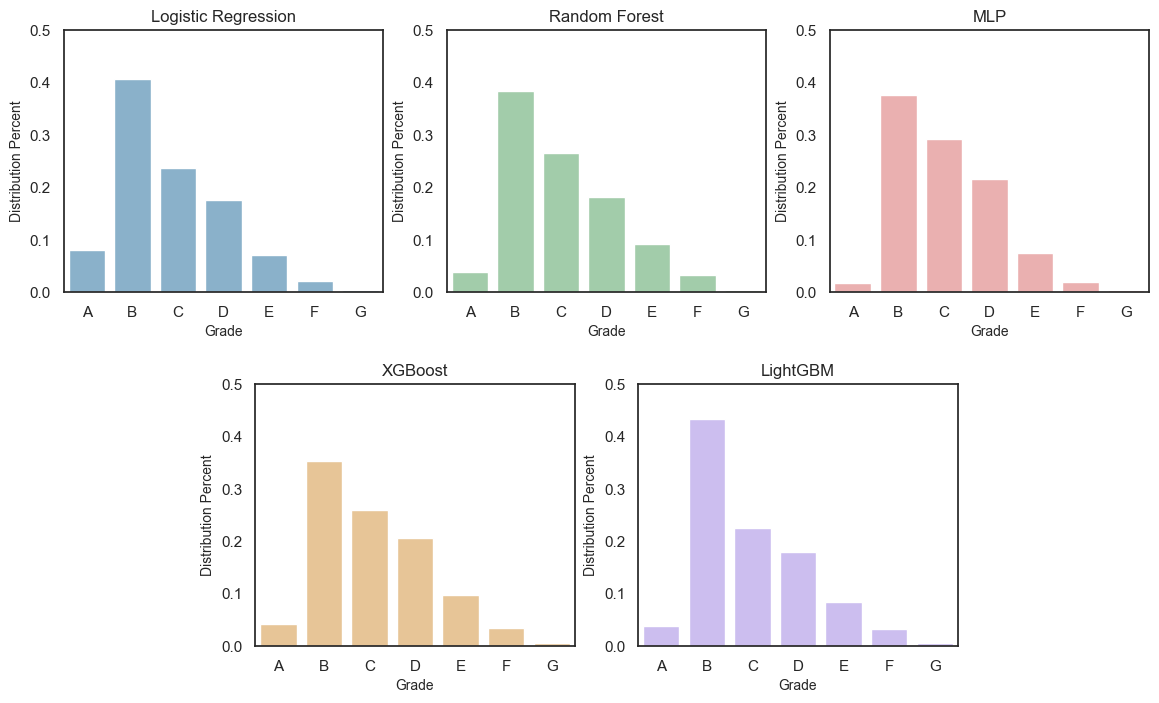

In [ ]:
model_colors = {
    'Logistic Regression': '#7FB3D5', 
    'Random Forest': '#9BD3A6',
    'MLP': '#F4A6A6',
    'XGBoost': '#F4C78A',
    'LightGBM': '#C9B6F7',
}

plots_data = [
    ('Logistic Regression', lr_grade, (0, slice(0, 2))), 
    ('Random Forest', rf_grade, (0, slice(2, 4))),  
    ('MLP', mlp_grade, (0, slice(4, 6))),  
    ('XGBoost', xgb_grade, (1, slice(1, 3))),  
    ('LightGBM', lgbm_grade, (1, slice(3, 5))), 
]

fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.35, wspace=0.50)

for title, data, (row, col) in plots_data:
    ax = fig.add_subplot(gs[row, col])

    sns.barplot(data=data, x='grade', y='pct', color=model_colors[title], ax=ax)

    ax.set_title(f'{title}')
    ax.set_xlabel('Grade', fontsize=10)
    ax.set_ylabel('Distribution Percent', fontsize=10)
    ax.set_ylim(0, 0.5)

plt.show()

### Realised Portfolio Outcomes

In [29]:
def calculate_realised_metrics(selected_df, lgd=0.4):
    df = selected_df.copy()

    df["realised_loss"] = (df["loan_status"] * lgd * df["loan_amnt"] * df["weight"]).round(2)
    df["weighted_int_income"] = (df["int_income"] * df["weight"]).round(2)
    df["realised_profit"] = (df["weighted_int_income"] - df["realised_loss"]).round(2)

    total_expected_profit = (df["expected_profit"] * df["weight"]).sum()
    total_realised_profit = df["realised_profit"].sum()
    total_expected_loss = (df["expected_loss"] * df["weight"]).sum()
    total_realised_loss = df["realised_loss"].sum()
    default_rate = (df["loan_status"] * df["weight"]).sum() / df["weight"].sum()

    return {
        "expected_profit": total_expected_profit,
        "realised_profit": total_realised_profit,
        "profit_difference": total_realised_profit - total_expected_profit,
        "profit_realisation_pct": (total_realised_profit / total_expected_profit)* 100,
        "expected_loss": total_expected_loss,
        "realised_loss": total_realised_loss,
        "realised_default_rate": default_rate,
    }

In [30]:
selected_portfolios = {
    "Logistic Regression": lr_selected,
    "MLP": mlp_selected,
    "Random Forest": rf_selected,
    "XGBoost": xgb_selected,
    "LightGBM": lgbm_selected,
}

realised_results = []
for name, portfolio in selected_portfolios.items():
    metrics = calculate_realised_metrics(portfolio)
    metrics["model"] = name
    realised_results.append(metrics)

outcomes_df = pd.DataFrame(realised_results)[
    [
        "model",
        "expected_profit",
        "realised_profit",
        "profit_difference",
        "profit_realisation_pct",
        "expected_loss",
        "realised_loss",
        "realised_default_rate",
    ]
]

outcomes_df

,model,expected_profit,realised_profit,profit_difference,profit_realisation_pct,expected_loss,realised_loss,realised_default_rate
0,Logistic Regression,10186536.47,9886650.03,-299886.44,97.056051,4864583.56,5164470.0,0.123897
1,MLP,11631438.86,9974019.66,-1657419.20,85.750523,4066890.80,5724310.0,0.134264
2,Random Forest,11562616.46,10267638.46,-1294978.00,88.800303,3763592.00,5058570.0,0.122327
3,XGBoost,11765374.56,11329424.33,-435950.23,96.294634,3981249.77,4417200.0,0.106581
4,LightGBM,10306518.59,10662536.86,356018.27,103.454302,5012408.27,4656390.0,0.111860


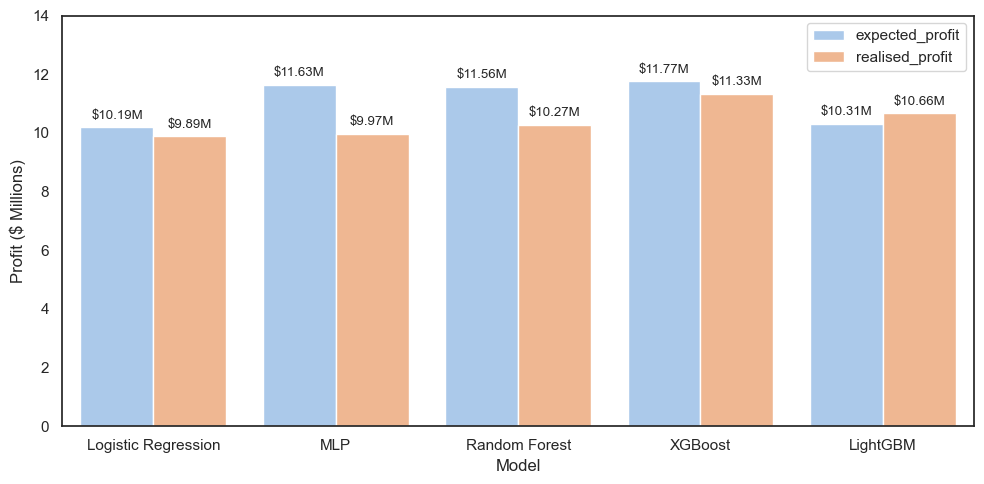

In [31]:
plot_df = outcomes_df.melt(
    id_vars="model",
    value_vars=["expected_profit", "realised_profit"],
    var_name="Profit_Type",
    value_name="amount",
)

# convert values to millions
plot_df["amount"] = plot_df["amount"] / 1000000

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=plot_df, x="model", y="amount", hue="Profit_Type")

for container in ax.containers:
    ax.bar_label(container, fmt="$%.2fM", padding=4, fontsize=9.5)

plt.ylabel("Profit ($ Millions)")
plt.xlabel("Model")
plt.ylim(0, 14)
plt.legend()
plt.tight_layout()
plt.show()

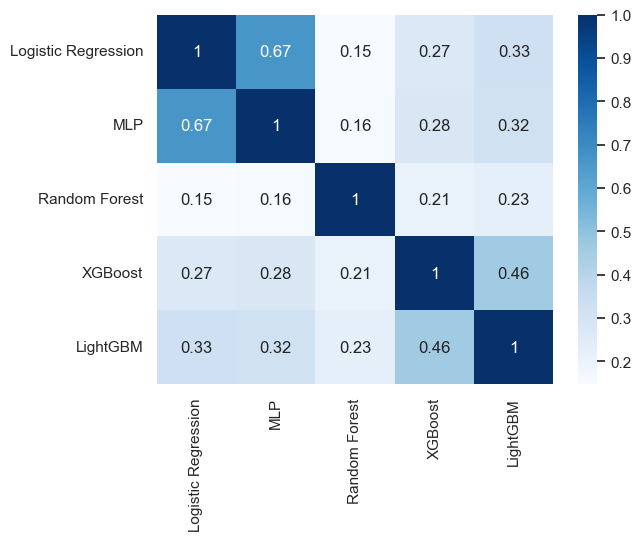

In [32]:
# portfolio pairwise overlap
from itertools import combinations

model_ids = {name: set(df['id']) for name, df in selected_portfolios.items()}
overlap_matrix = pd.DataFrame(index=model_ids.keys(), columns=model_ids.keys(), dtype=float)

for m1, m2 in combinations(model_ids.keys(), 2):
    inter = len(model_ids[m1].intersection(model_ids[m2]))
    union = len(model_ids[m1].union(model_ids[m2]))
    jaccard = inter / union
    overlap_matrix.loc[m1, m2] = overlap_matrix.loc[m2, m1] = jaccard

np.fill_diagonal(overlap_matrix.values, 1.0)
sns.heatmap(overlap_matrix, annot=True, cmap='Blues');